In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')
df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [5]:
df.shape

(80000, 31)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
#checking missing values
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

,0
student_id,0
age,0
gender,0
major,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0


In [9]:
# Remove unnecessary columns
df = df.drop(columns=['student_id','index','major','previous_gpa','time_management_score','learning_style','exam_anxiety_score','motivation_level','parental_support_level','family_income_range','study_environment','semester','screen_time','social_activity','dropout_risk','stress_level','access_to_tutoring', 'attendance_percentage','exercise_frequency','diet_quality','parental_education_level','internet_quality','mental_health_rating','extracurricular_participation','exam_score'], errors='ignore')
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,sleep_hours
0,26,Male,7.645367,3.0,0.1,Yes,6.2
1,28,Male,5.700000,0.5,0.4,No,7.2
2,17,Male,2.400000,4.2,0.7,No,9.2
3,27,Other,3.400000,4.6,2.3,Yes,4.2
4,25,Female,4.700000,0.8,2.7,Yes,6.5


In [10]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,sleep_hours
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,22.004288,4.174388,2.501366,1.997754,7.017417
std,3.745570,2.004135,1.445441,1.155992,1.467377
min,16.000000,0.000000,0.000000,0.000000,4.000000
25%,19.000000,2.800000,1.200000,1.000000,6.000000
50%,22.000000,4.125624,2.500000,2.000000,7.000000
75%,25.000000,5.500000,3.800000,3.000000,8.000000
max,28.000000,12.000000,5.000000,4.000000,12.000000


In [11]:
#removing duplicates
df = df.drop_duplicates()


In [12]:
#remove rows where sleep_hours is too high or too low
Q1 = df['sleep_hours'].quantile(0.25)
Q3 = df['sleep_hours'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['sleep_hours'] < (Q1 - 1.5 * IQR)) | (df['sleep_hours'] > (Q3 + 1.5 * IQR)))]


In [13]:
# Remove rows where study_hours_per_day is too high or too low
Q1 = df['study_hours_per_day'].quantile(0.25)
Q3 = df['study_hours_per_day'].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df['study_hours_per_day'] < (Q1 - 1.5 * IQR)) |
          (df['study_hours_per_day'] > (Q3 + 1.5 * IQR)))]

In [14]:
df.shape

(79364, 7)

In [15]:
#define total social hours per day
df['total_social_hours'] = df['netflix_hours'] + df['social_media_hours']

In [16]:
#define focus ratio
df['focus_ratio'] = df['study_hours_per_day'] / (
    df['study_hours_per_day'] + df['total_social_hours'] + 1
)

In [17]:
#define task completed
threshold = 0.5

df['task_completed'] = (
    df['focus_ratio'] +
    np.random.normal(0, 0.1, len(df))  #noise
    > threshold
).astype(int)

In [18]:
df['task_completed'].value_counts()


,count
task_completed,
0,52025
1,27339


In [19]:
features = [
    'age',
    'gender',
    'part_time_job',
    'study_hours_per_day',
    'sleep_hours',
    'total_social_hours'
]

X = df[features].copy()
y = df['task_completed'].copy()

In [20]:
#    - One-hot encode categorical columns
X = pd.get_dummies(X, columns=['gender', 'part_time_job'], drop_first=True)

In [21]:
#    - Scale numeric columns
num_cols = ['age', 'study_hours_per_day', 'sleep_hours', 'total_social_hours']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [22]:
#apply smote
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

In [23]:
#split the data set to train and test
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)

In [24]:
print("y (original):")
print(y.value_counts())

print("\ny_bal (after SMOTE on full dataset):")
print(y_bal.value_counts())

print("\ny_train_bal (after split):")
print(y_train_bal.value_counts())

print("\ny_test_bal (after split):")
print(y_test_bal.value_counts())

y (original):
task_completed
0    52025
1    27339
Name: count, dtype: int64

y_bal (after SMOTE on full dataset):
task_completed
1    52025
0    52025
Name: count, dtype: int64

y_train_bal (after split):
task_completed
1    41620
0    41620
Name: count, dtype: int64

y_test_bal (after split):
task_completed
1    10405
0    10405
Name: count, dtype: int64


In [25]:
#decision tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_bal)

print("Accuracy:", round(accuracy_score(y_test_bal, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test_bal, y_pred))


Accuracy: 0.811

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81     10405
           1       0.81      0.80      0.81     10405

    accuracy                           0.81     20810
   macro avg       0.81      0.81      0.81     20810
weighted avg       0.81      0.81      0.81     20810



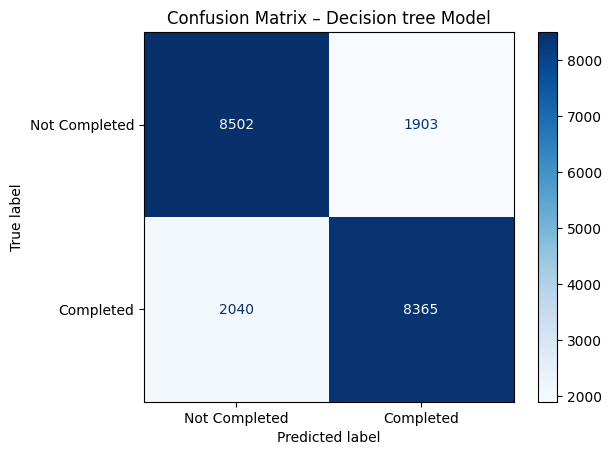

In [27]:
#evaluating the model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



# Generate confusion matrix
cm = confusion_matrix(y_test_bal, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Completed', 'Completed'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Decision tree Model")
plt.show()

In [28]:
#random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [29]:
y_pred = rf_model.predict(X_test_bal)

In [30]:
#evaluating
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test_bal, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82     10405
           1       0.81      0.85      0.83     10405

    accuracy                           0.82     20810
   macro avg       0.82      0.82      0.82     20810
weighted avg       0.82      0.82      0.82     20810



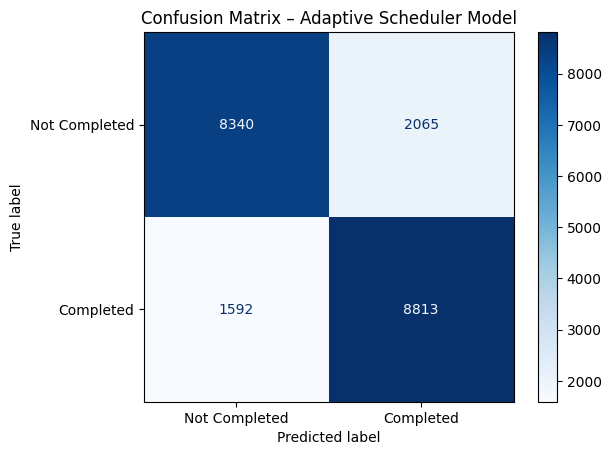

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test_bal, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Completed', 'Completed']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Adaptive Scheduler Model")
plt.show()

In [32]:
#logistic regression model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # helps with class imbalance
    random_state=42
)

log_model.fit(X_train_bal, y_train_bal)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [33]:
y_pred_lr = log_model.predict(X_test_bal)

In [34]:
#evaluation
from sklearn.metrics import classification_report

accuracy_lr = accuracy_score(y_test_bal, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

print("Classification Report (Logistic Regression):")
print(classification_report(y_test_bal, y_pred_lr))

Logistic Regression Accuracy: 0.8147525228255647
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     10405
           1       0.81      0.83      0.82     10405

    accuracy                           0.81     20810
   macro avg       0.81      0.81      0.81     20810
weighted avg       0.81      0.81      0.81     20810



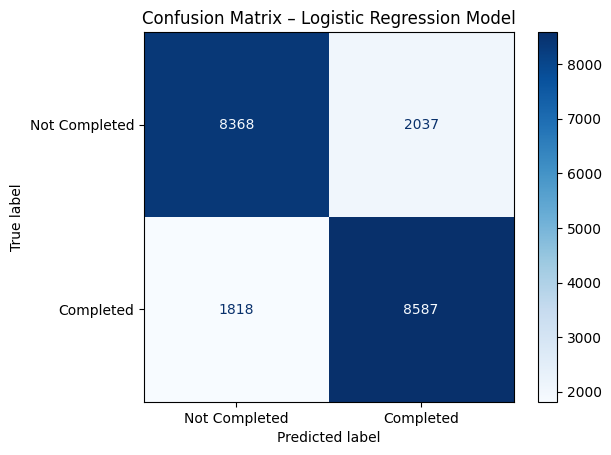

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test_bal, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['Not Completed', 'Completed']
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression Model")
plt.show()

In [36]:
#tuning the dt model
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define base model
dt = DecisionTreeClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # better than accuracy for imbalance
    n_jobs=-1
)

grid_search.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 50}


In [37]:
#train the model
best_dt = grid_search.best_estimator_

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_dt.predict(X_test_bal)

print("Tuned Decision Tree Accuracy:", round(accuracy_score(y_test_bal, y_pred), 3))

print("\nClassification Report:")
print(classification_report(y_test_bal, y_pred))



Tuned Decision Tree Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82     10405
           1       0.81      0.83      0.82     10405

    accuracy                           0.82     20810
   macro avg       0.82      0.82      0.82     20810
weighted avg       0.82      0.82      0.82     20810



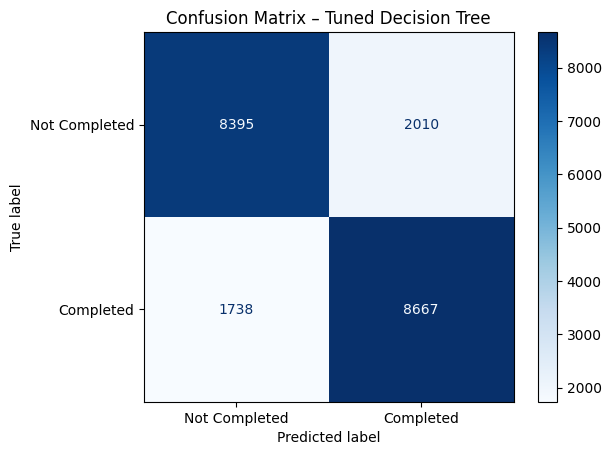

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_dt,
    X_test_bal,
    y_test_bal,
    display_labels=['Not Completed', 'Completed'],
    cmap='Blues'
)

plt.title("Confusion Matrix – Tuned Decision Tree")
plt.show()

In [40]:
#tuning the lr model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Base logistic regression
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

# Small + effective grid (fast)
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="f1",     # best for imbalance
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = best_lr.predict(X_test_bal)

print("Tuned Logistic Regression Accuracy:", round(accuracy_score(y_test_bal, y_pred_lr), 3))
print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test_bal, y_pred_lr))


Tuned Logistic Regression Accuracy: 0.814

Classification Report (Tuned Logistic Regression):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     10405
           1       0.81      0.83      0.82     10405

    accuracy                           0.81     20810
   macro avg       0.81      0.81      0.81     20810
weighted avg       0.81      0.81      0.81     20810



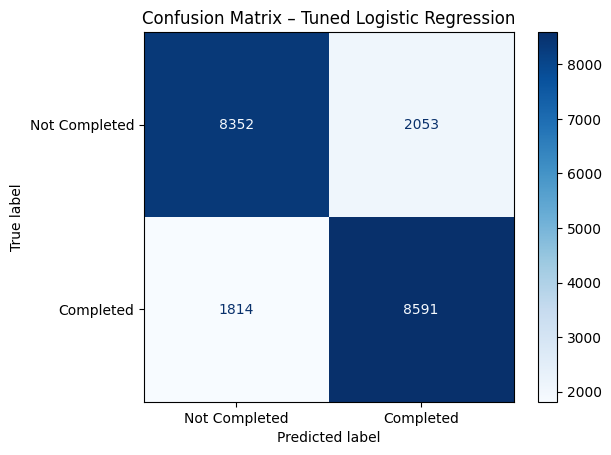

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test_bal,
    y_test_bal,
    display_labels=['Not Completed', 'Completed'],
    cmap='Blues'
)

plt.title("Confusion Matrix – Tuned Logistic Regression")
plt.show()

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Base model (fast settings for tuning)
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Small grid = low running time
param_grid = {
    "n_estimators": [100, 150],     # smaller range
    "max_depth": [8, 12],           # controlled depth
    "min_samples_split": [10, 20],
    "min_samples_leaf": [5, 10],
    "max_features": ["sqrt"]        # fix to reduce search
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,               # faster than 5-fold
    scoring="f1",       # better for imbalance
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 150}


In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_rf = best_rf.predict(X_test_bal)

print("Tuned Random Forest Accuracy:", round(accuracy_score(y_test_bal, y_pred_rf), 3))
print("\nClassification Report:")
print(classification_report(y_test_bal, y_pred_rf))


Tuned Random Forest Accuracy: 0.828

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82     10405
           1       0.82      0.85      0.83     10405

    accuracy                           0.83     20810
   macro avg       0.83      0.83      0.83     20810
weighted avg       0.83      0.83      0.83     20810



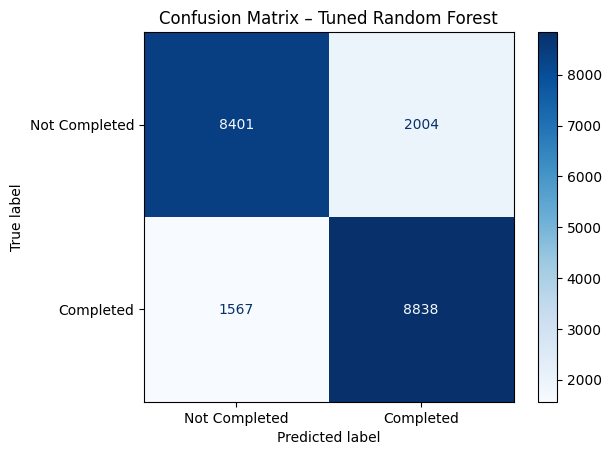

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test_bal,
    y_test_bal,
    display_labels=['Not Completed', 'Completed'],
    cmap='Blues'
)
plt.title("Confusion Matrix – Tuned Random Forest")
plt.show()

In [46]:

feature_importance = pd.DataFrame({
    'feature': X_train_bal.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)

,feature,importance
1,study_hours_per_day,0.573847
3,total_social_hours,0.386889
0,age,0.020107
2,sleep_hours,0.015356
6,part_time_job_Yes,0.001466
4,gender_Male,0.001196
5,gender_Other,0.001139


In [47]:
#check the overfitting for tuned rf model
train_pred = best_rf.predict(X_train_bal)

print("Train Accuracy:",
      round(accuracy_score(y_train_bal, train_pred), 3))

print("Test Accuracy:",
      round(accuracy_score(y_test_bal, y_pred_rf), 3))

Train Accuracy: 0.851
Test Accuracy: 0.828


In [48]:
#ROC_AUC score
from sklearn.metrics import roc_auc_score

y_prob_rf = best_rf.predict_proba(X_test_bal)[:, 1]
roc_auc = roc_auc_score(y_test_bal, y_prob_rf)

print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC Score: 0.915


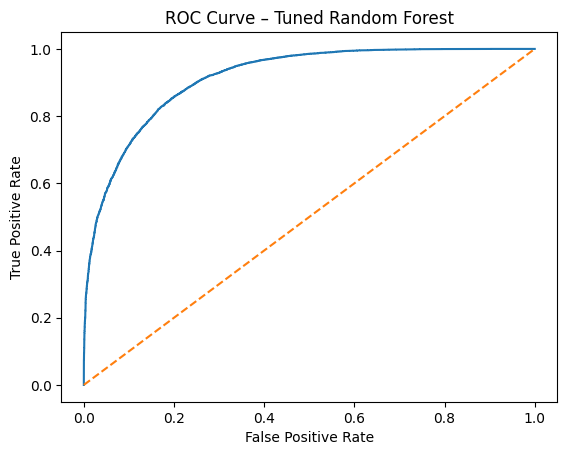

In [49]:
#ROC curve plot
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test_bal, y_prob_rf)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tuned Random Forest")
plt.show()

In [50]:
#Cross-Validation Score (Model Stability)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_train_bal, y_train_bal, cv=3, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", round(cv_scores.mean(), 3))

Cross-validation F1 scores: [0.8342068  0.83496518 0.83255419]
Mean CV F1 score: 0.834
